# 01 — Carry & Curve Calibration (Phase 2)

Implied convenience-yield term structure and a Schwartz–Smith (2000) two-factor fit, all from the **frozen** coffee chain (`data/frozen/`, SHA-256 manifest, gates PASS). Analytics live in `hedging_workbench`; this notebook orchestrates and explains.

Frozen snapshot: 2026-09-04 · Primary: KC=F coffee · Gold GC=F fallback armed but not used.

In [1]:
import pandas as pd

from hedging_workbench.carry import curve_state, load_curve, yield_term_structure
from hedging_workbench.ssfit import fit_curve
from hedging_workbench.data.frozen import load
from hedging_workbench.vol import vol_from_frozen
from hedging_workbench.data.frozen import latest_rate

import matplotlib.pyplot as plt
import numpy as np

curve = load_curve("coffee")
ts = yield_term_structure(curve)   # r = latest frozen SOFR
r = ts.attrs["r"]
print(f"curve date {curve.attrs['curve_date'].date()}  r(SOFR) {r:.4f}")
curve

curve date 2026-09-04  r(SOFR) 0.0366


,symbol,label,expiry,price,ttm
0,KCU26.NYB,Sep 2026,2026-09-15,324.250000,0.030116
1,KCZ26.NYB,Dec 2026,2026-12-15,295.600006,0.279261
2,KCH27.NYB,Mar 2027,2027-03-15,287.399994,0.525667
3,KCK27.NYB,May 2027,2027-05-15,285.049988,0.692676
4,KCN27.NYB,Jul 2027,2027-07-15,283.399994,0.859685
5,KCU27.NYB,Sep 2027,2027-09-15,281.450012,1.029432
6,KCZ27.NYB,Dec 2027,2027-12-15,278.750000,1.278576
7,KCH28.NYB,Mar 2028,2028-03-15,276.899994,1.527721


## 1. Implied convenience-yield term structure

Cost-of-carry identity between consecutive maturities: $F_2 = F_1\,e^{(r+d-y)\tau}$.
The implied **total carry** is $c = \ln(F_2/F_1)/\tau$ (negative = backwardation);
the implied **convenience yield** is $y = r + d - c$, with storage outlay $d$
**not separately identifiable** from spreads alone — we report $y$ gross of
storage ($d=0$) and quantify $d$'s role below.

state: backwardation


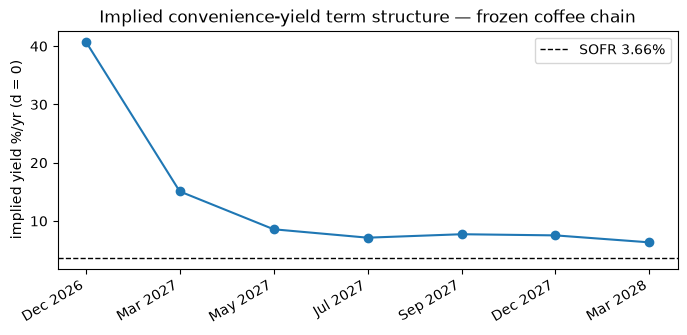

In [2]:
ts.style.format({
    "tau": "{:.3f}", "f_near": "{:.2f}", "f_far": "{:.2f}",
    "carry": "{:+.3f}", "implied_yield": "{:+.3f}"})
print(f"state: {curve_state(ts)}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts["far"], ts["implied_yield"] * 100, "o-")
ax.axhline(r * 100, color="k", ls="--", lw=1, label=f"SOFR {r*100:.2f}%")
ax.set_ylabel("implied yield %/yr (d = 0)")
ax.set_title("Implied convenience-yield term structure — frozen coffee chain")
ax.legend(); fig.autofmt_xdate(); plt.show()

Reading: the curve is **backwardation at every spread** — the front (Sep→Dec 26)
spread prices a 41%/yr convenience yield, decaying to
~6%/yr further out. This closes Phase 1's disclosed gap:
the −8…−9%/yr figure there was a **curve-average** total carry
$\bar{c} = -9.6\%$/yr; the decomposition is steep —
near-dated scarcity (y ≫ r) flattening toward y ≈ r + d at the back. Any
positive storage outlay d shifts y up one-for-one; the near-dated
backwardation (~37%/yr total carry) is far too large for
storage costs to explain, so it is a genuine convenience-yield / scarcity
signal.

## 2. Schwartz–Smith (2000) two-factor fit

Log spot $= \chi_t + \xi_t$: OU short-term deviation ($\kappa$) + GBM equilibrium
level. Futures: $\ln F(\tau) = \chi e^{-\kappa\tau} + \xi + A(\tau)$. With a single
snapshot, $A(\tau)$'s vol/drift terms are **not identifiable** — the fit uses
the reduced form $A(\tau) \to B\tau$ (documented choice); volatility
parameters would need the time-series Kalman MLE. 8 maturities vs 4
parameters: $\kappa$ identification is thin — standard errors reported, not hidden.

,value
chi (spot deviation),+0.1308 ± 0.0018
xi (log long-run level),5.6732 ± 0.0018
long-run price (¢/lb),291.0
kappa (1/yr),5.97 ± 0.25
half-life (yr),0.12
slope B (1/yr),-0.0328 ± 0.0015
log-space RMSE,0.00063


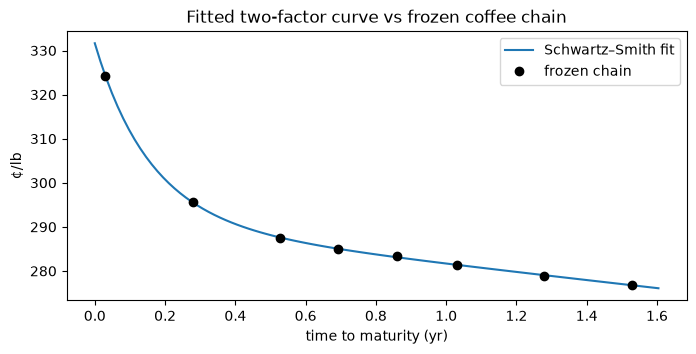

In [3]:
fit = fit_curve(curve)
tau_grid = np.linspace(0, curve["ttm"].max() * 1.05, 100)

display(pd.Series({
    "chi (spot deviation)": f"{fit.chi:+.4f} ± {fit.se['chi']:.4f}",
    "xi (log long-run level)": f"{fit.xi:.4f} ± {fit.se['xi']:.4f}",
    "long-run price (¢/lb)": f"{fit.long_run_price:.1f}",
    "kappa (1/yr)": f"{fit.kappa:.2f} ± {fit.se['kappa']:.2f}",
    "half-life (yr)": f"{fit.half_life:.2f}",
    "slope B (1/yr)": f"{fit.slope:+.4f} ± {fit.se['slope']:.4f}",
    "log-space RMSE": f"{fit.rmse:.5f}",
}).to_frame("value"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(tau_grid, np.exp(fit.forward(tau_grid)), label="Schwartz–Smith fit")
ax.plot(curve["ttm"], curve["price"], "ko", label="frozen chain")
ax.set_xlabel("time to maturity (yr)"); ax.set_ylabel("¢/lb")
ax.set_title("Fitted two-factor curve vs frozen coffee chain")
ax.legend(); plt.show()

The two-factor shape nails the snapshot (RMSE 0.06% in log
space): a mean-reverting deviation with a **1.4-month half-life**
on top of a ~291 ¢/lb long-run equilibrium drifting
-3.3%/yr. Interview-ready caveat: with one snapshot, $\kappa$'s
standard error (0.25) comes from the Jacobian, not from
time-series information — the honest statement is 'identified on this
snapshot', not 'estimated from dynamics'.

## 3. Volatility: GARCH(1,1) replaces the preliminary EWMA

Phase 1 used a preliminary EWMA (λ=0.94) vol of 46.2%/yr. GARCH(1,1) is
fitted on the same frozen KC=F daily returns in percent (arch's scale);
EWMA is the λ-fixed special case of the same filter, so the upgrade is the
*estimated* persistence.

In [4]:
rets, fit_v = vol_from_frozen()

print(f"alpha+beta = {fit_v.persistence:.4f}  (→1 = near-IGARCH/EWMA persistence)")
print(f"GARCH long-run vol  : {fit_v.garch_longrun:5.1f}%/yr")
print(f"GARCH conditional   : {fit_v.garch_last:5.1f}%/yr  (as of curve date)")
print(f"EWMA (λ=0.94)       : {fit_v.ewma_annual:5.1f}%/yr  (Phase 1 preliminary: 46.2%)")

alpha+beta = 0.8025  (→1 = near-IGARCH/EWMA persistence)
GARCH long-run vol  :  38.5%/yr
GARCH conditional   :  39.2%/yr  (as of curve date)
EWMA (λ=0.94)       :  47.2%/yr  (Phase 1 preliminary: 46.2%)


**Model note.** GARCH(1,1) log-likelihood -1541.8 with
persistence α+β = 0.802; EWMA is the λ=0.94 constraint of the same
filter, so the comparison is not a likelihood test — the upgrade is that the
persistence is *estimated*, not imposed. Working vol from here on:
**GARCH long-run 38.5%/yr** (EWMA's 46.2% was inflated by the
2024–25 price spike in its window; the mean-reverting GARCH long-run level
is lower and feeds Phase 3's collar strikes and Phase 5's exposure profiles).

## 4. Limitations

- Single frozen snapshot: S–S volatility parameters and $\kappa$ dynamics not
  estimated from time series (Kalman MLE = future work); reduced-form drift.
- Contract expiry approximated as the 15th of the delivery month (cancels to
  first order in spread *differences*).
- $d$ (storage) assumed 0: $y$ is gross of storage; not separately identifiable
  from spreads.
- Unofficial source (Yahoo), frozen 2026-09-04 — nothing here is live data.